# E4 — Retrieval in Sixty Seconds

> ### 🧪 Enrichment — **not examinable**
> The official Unit 2 content is in `../examples/`. Nothing in this notebook appears in a quiz, the
> final exam, or any graded task. It exists because retrieval is the single biggest change in applied
> NLP since this course was designed, and because you can build a working one in under a minute with
> tools you already have.

## 📚 Learning Objectives

By completing this notebook, you will:
- Turn a folder of real documents into a searchable index using only `scikit-learn` and NumPy
- Implement **BM25** from its formula and compare it against TF-IDF cosine similarity on the same queries
- Measure retrieval quality with **hit@1** and **hit@3** on a small labelled query set
- State, from your own output, why *retrieval is not an answer* — the failure that defines RAG systems

## 🔗 Where this fits

**Builds on:** Unit 2 lesson 01 (tokenization — a retriever is a tokenizer plus a weighting scheme) and
lesson 02 (word embeddings — the *dense* half of the same job). Unit 3 lesson 01 built the TF-IDF matrix
you are about to reuse for search instead of classification.

**Used later in:** Unit 4 lesson 03 and lesson 05 both tell you that when a model needs *facts*, you
retrieve them instead of fine-tuning them in. This notebook is the retrieval half of that sentence, made
concrete. Course 11 (Deploying AI Models) is where the same index becomes a service.


## 🌍 Why this matters: the thing between the user and the model

In 2020 Lewis et al. published *Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks*
([arXiv:2005.11401](https://arxiv.org/abs/2005.11401)): instead of hoping a language model memorised a
fact during training, **fetch the passage that contains it and put it in the prompt.** That one idea is
now the default architecture for corporate chat over private documents, and it is why an organization
with data-residency obligations can use a model without shipping its documents into the model's weights.

**What goes wrong without this lesson.** Teams reach for fine-tuning to "teach the model our documents".
It is the wrong tool: it is expensive, it must be redone whenever a document changes, it produces no
citation the reader can check, and it still hallucinates. Retrieval is cheap, updates instantly, and
every answer can point at the passage it came from.

**The uncomfortable half nobody demos.** A retriever *always* returns something. Ask it a question whose
answer is not in the corpus and it will hand back the nearest text with a respectable-looking score;
attach a fluent language model to that and you have manufactured a confident wrong answer with a
citation. You will produce exactly that failure in Part 5, deliberately.


## 📥 Inputs & 📤 Outputs

**Inputs:** the **72 real README files** of this repository — one per course and one per unit. No
downloads, no API keys, no network. They are ordinary prose written for students, which makes them a
realistic and slightly awkward corpus: repetitive vocabulary, headings that repeat across courses, and
no ground-truth labels of any kind.

**Outputs:** a chunk table with counts, two ranked result lists (TF-IDF and BM25) for the same queries,
hit@1 / hit@3 for both methods on 7 labelled questions, a comparison chart, and one deliberately
unanswerable query showing what a retriever does when the answer does not exist.


## Part 1: The Corpus — Real Files, Not a Toy List

Every retrieval system starts the same way: point at a folder, read what is there, and refuse to
continue if it is not what you expected. The check below is not decoration — an index silently built
over 3 files instead of 72 is the most common cause of "the search doesn't work" in production.


In [1]:
# Step 1: locate the repository root and load the real corpus.
# We walk UP from the notebook's own folder until we see the course directories,
# so this works no matter where the repo lives on your machine.
from pathlib import Path
import re
import numpy as np
import pandas as pd

def find_repo_root(start: Path) -> Path:
    """Return the first parent directory that contains both 'Course 01' and 'Course 12'.

    WHY: walking UP from the working directory is what makes this portable. It resolves the
    same whether the kernel started in this folder, at the repository root, or anywhere
    between - no '../../..' to break. The corpus of this lesson is the repository's own README
    files, so it genuinely needs the clone on disk; the message below says how to get one.
    """
    for parent in [start, *start.parents]:
        if (parent / "Course 01").is_dir() and (parent / "Course 12").is_dir():
            return parent
    raise RuntimeError(
        f"No AI Diploma repository above {start}.\n"
        "This lesson indexes this repository's own README files, so it needs the repository "
        "on disk - there is no data file to download instead. Get it with:\n"
        "    git clone --depth 1 https://github.com/A-Alwabel/AI-Diploma-Program\n"
        "then open this notebook from inside the clone. On Google Colab, run that clone in a "
        "cell first and %cd into it, then re-run this cell."
    )

REPO = find_repo_root(Path.cwd())

# The corpus: one README per course, plus one per unit. All real, all already on disk.
paths = sorted(REPO.glob("Course */README.md")) + sorted(REPO.glob("Course */unit*/README.md"))

# Fail loudly rather than indexing an empty folder — a silent empty index looks like a bad model.
if len(paths) < 50:
    raise RuntimeError(f"Expected 70+ README files, found {len(paths)}. Has the repo layout changed?")

docs = []
for p in paths:
    rel = p.relative_to(REPO)
    docs.append({
        "rel": str(rel),                 # human-readable id, e.g. "Course 09/unit3-deep-rl/README.md"
        "course": rel.parts[0],          # the folder we will grade retrieval against
        "text": p.read_text(encoding="utf-8"),
    })

total_words = sum(len(d["text"].split()) for d in docs)
print(f"Corpus loaded: {len(docs)} README files from {len({d['course'] for d in docs})} courses")
print(f"Total words   : {total_words:,}")
print(f"Longest file  : {max(docs, key=lambda d: len(d['text'].split()))['rel']}")
print("\nFirst five documents:")
for d in docs[:5]:
    print(f"  {len(d['text'].split()):5d} words  {d['rel']}")


Corpus loaded: 72 README files from 12 courses
Total words   : 23,360
Longest file  : Course 08/README.md

First five documents:
    447 words  Course 01/README.md
    453 words  Course 02/README.md
    559 words  Course 03/README.md
    582 words  Course 04/README.md
    585 words  Course 05/README.md


## Part 2: Chunking — Why You Never Index Whole Files

A retriever's job is to return a **passage a reader can act on**, not a 600-word file they must then
search by eye. So documents are cut into chunks before indexing. Chunk too coarsely and every result is
mostly irrelevant text; chunk too finely and you cut the answer in half.

Markdown gives us free structure: split before every `#`/`##`/`###` heading and each chunk is a section
its author already decided was one idea. We prepend the heading to the body, because the heading is often
the only place the topic word appears.


In [2]:
# Step 2: cut every README into heading-delimited chunks.
MIN_WORDS = 12   # drop stubs like a two-line "## Setup" section: too short to be a useful answer

def split_into_chunks(text: str, rel: str, course: str) -> list[dict]:
    """Split markdown before each level 1-3 heading; keep the heading as part of the chunk text."""
    parts = re.split(r"\n(?=#{1,3} )", text)      # lookahead: split BEFORE the heading, keep it
    out = []
    for part in parts:
        lines = [ln for ln in part.strip().split("\n") if ln.strip()]
        if not lines:
            continue
        if lines[0].startswith("#"):
            heading, body_lines = lines[0].lstrip("# ").strip(), lines[1:]
        else:
            heading, body_lines = "(intro)", lines
        body = " ".join(body_lines).strip()
        if len(body.split()) >= MIN_WORDS:
            out.append({"rel": rel, "course": course, "heading": heading,
                        "text": f"{heading}. {body}"})
    return out

chunks = [c for d in docs for c in split_into_chunks(d["text"], d["rel"], d["course"])]
chunks_df = pd.DataFrame(chunks)

lengths = chunks_df["text"].str.split().str.len()
print(f"{len(docs)} files -> {len(chunks_df)} chunks")
print(f"Chunk length (words): median {lengths.median():.0f}, min {lengths.min()}, max {lengths.max()}")
print(f"Chunks per course   : min {chunks_df['course'].value_counts().min()}, "
      f"max {chunks_df['course'].value_counts().max()}")
print("\nThree chunks, so you can see what the index actually holds:\n")
for i in (0, len(chunks_df) // 2, len(chunks_df) - 1):
    row = chunks_df.iloc[i]
    print(f"[{i}] {row['rel']}  ::  {row['heading']}")
    print(f"     {row['text'][:150]}...\n")


72 files -> 370 chunks
Chunk length (words): median 42, min 13, max 285
Chunks per course   : min 23, max 39

Three chunks, so you can see what the index actually holds:

[0] Course 01/README.md  ::  AIAT 111 - Introduction to Artificial Intelligence and Applications
     AIAT 111 - Introduction to Artificial Intelligence and Applications. **New students: read `START_HERE.md` first.** It covers setup and the exact order...

[185] Course 04/unit5-model-selection/README.md  ::  Exercises
     Exercises. Each exercise exists as a notebook (`.ipynb`) and an equivalent script (`.py`) - use the notebook form on the **ai-diploma** kernel. 1. `ex...

[369] Course 12/unit5-documentation-presentation/README.md  ::  Exercise
     Exercise. This unit has no separate exercise notebook; the practical work is documenting and presenting your own project. Use the templates: - [../TEM...



## Part 3: Two Retrievers on the Same Index

**TF-IDF + cosine similarity** (Unit 3) treats every chunk as a weighted word vector and ranks by angle.
It is the retrieval baseline that has not gone away.

**BM25** is what search engines actually use. It is the same idea with two corrections that matter:

- **Term-frequency saturation.** In TF-IDF, a chunk saying "transformer" ten times scores roughly ten
  times a chunk saying it once. BM25 applies `tf·(k₁+1) / (tf + k₁·…)`, so the second mention counts a
  lot and the tenth counts almost nothing. Repetition stops being a ranking strategy.
- **Length normalization you can tune.** The `b` parameter controls how hard long chunks are penalised
  for containing more words by accident.

We implement it directly from the formula in NumPy — about fifteen lines — so nothing is hidden.


In [3]:
# Step 3a: TF-IDF + cosine similarity, the baseline retriever.
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.metrics.pairwise import cosine_similarity

tfidf_vec = TfidfVectorizer(lowercase=True, stop_words="english", sublinear_tf=True)
TFIDF = tfidf_vec.fit_transform(chunks_df["text"])          # (n_chunks x vocab), sparse

def retrieve_tfidf(query: str, k: int = 3):
    """Rank chunks by cosine similarity between the query vector and every chunk vector."""
    q = tfidf_vec.transform([query])                        # the query is embedded the SAME way
    scores = cosine_similarity(q, TFIDF).ravel()
    top = np.argsort(-scores)[:k]                           # argsort of the negative = descending
    return [(int(i), float(scores[i])) for i in top]

# Step 3b: BM25, implemented from the formula so you can see every term.
count_vec = CountVectorizer(lowercase=True, stop_words="english")
TF = count_vec.fit_transform(chunks_df["text"]).toarray().astype(float)   # raw counts
N, V = TF.shape

k1, b = 1.5, 0.75                       # the standard BM25 constants
doc_freq = (TF > 0).sum(axis=0)                                  # how many chunks contain each term
idf = np.log(1.0 + (N - doc_freq + 0.5) / (doc_freq + 0.5))      # rare terms are worth more
doc_len = TF.sum(axis=1)                                         # words per chunk
avg_len = doc_len.mean()

# Saturating term frequency, normalized by chunk length -> the BM25 weight of every (chunk, term) pair.
denominator = TF + k1 * (1 - b + b * (doc_len / avg_len))[:, None]
BM25 = idf * (TF * (k1 + 1)) / denominator                       # (n_chunks x vocab)

bm25_vocab = count_vec.vocabulary_
analyzer = count_vec.build_analyzer()

def retrieve_bm25(query: str, k: int = 3):
    """Score = sum of the BM25 weights of the query's terms. Unknown words simply contribute nothing."""
    cols = [bm25_vocab[t] for t in analyzer(query) if t in bm25_vocab]
    if not cols:
        return []
    scores = BM25[:, cols].sum(axis=1)
    top = np.argsort(-scores)[:k]
    return [(int(i), float(scores[i])) for i in top]

print(f"TF-IDF index : {TFIDF.shape[0]} chunks x {TFIDF.shape[1]:,} terms")
print(f"BM25 index   : {N} chunks x {V:,} terms  (k1={k1}, b={b}, average chunk length {avg_len:.0f} words)")


TF-IDF index : 370 chunks x 2,424 terms
BM25 index   : 370 chunks x 2,424 terms  (k1=1.5, b=0.75, average chunk length 43 words)


In [4]:
# Step 4: ask both retrievers the same question and read the two ranked lists side by side.
def show(query: str, k: int = 3):
    print("=" * 100)
    print(f"QUERY: {query}")
    for name, hits in (("TF-IDF", retrieve_tfidf(query, k)), ("BM25  ", retrieve_bm25(query, k))):
        print(f"\n  {name}:")
        if not hits:
            print("    (no query term is in the vocabulary — the retriever has nothing to rank on)")
        for rank, (i, score) in enumerate(hits, 1):
            row = chunks_df.iloc[i]
            print(f"    {rank}. score={score:6.3f}  {row['rel']}  ::  {row['heading']}")
            print(f"       {row['text'][:130]}...")
    print()

show("how do I serve a trained model behind an API endpoint?")
show("which unit covers convolutional neural networks for images?")


QUERY: how do I serve a trained model behind an API endpoint?

  TF-IDF:
    1. score= 0.358  Course 08/unit5-deployment/README.md  ::  Exercise
       Exercise. - `exercises/01_deep_learning_model_deployment_exercise.ipynb` — optimize and deploy a trained model (export and/or API)...
    2. score= 0.190  Course 08/unit5-deployment/README.md  ::  What this unit teaches
       What this unit teaches. Making trained models smaller, faster, and servable: quantization, pruning, and knowledge distillation; ex...
    3. score= 0.174  Course 11/README.md  ::  Prerequisites
       Prerequisites. - Semester 1 (AIAT 111–116), including AIAT 114 — Machine Learning Algorithms (Course 04) - AIAT 122 — Deep Learnin...

  BM25  :
    1. score=12.880  Course 08/unit5-deployment/README.md  ::  Exercise
       Exercise. - `exercises/01_deep_learning_model_deployment_exercise.ipynb` — optimize and deploy a trained model (export and/or API)...
    2. score= 8.893  Course 08/unit5-deployment/README.md  :: 

## 💬 Discuss

1. Look at the two ranked lists above. Where they disagree, which ordering would you rather show a
   student — and can you point at the *reason* in the formula (saturation? length? IDF?) rather than
   just preferring the output you like?
2. The scores are on different scales: cosine similarity is bounded in [0, 1], BM25 is unbounded. A
   product manager asks you for "a confidence percentage" next to each search result. What is wrong
   with dividing a BM25 score by the top score and calling it confidence?
3. Our chunks are markdown sections written by one author for one audience. Name a document type in
   your own workplace where heading-based chunking would fail badly, and say what you would split on
   instead.


## Part 4: Measuring It — hit@1 and hit@3

An unmeasured retriever is a demo. Below are seven questions written against this corpus, each labelled
with the **course folder** whose README should answer it. Grading at folder level (rather than at exact
chunk level) keeps the labels honest: there is genuinely more than one reasonable passage per question,
but only one right course.

- **hit@1** — was the top result from the right course?
- **hit@3** — was *any* of the top three from the right course?

Seven queries is a tiny evaluation set, and Unit 3 already taught you what tiny test sets do to a metric.
Read these numbers as a smoke test, not as evidence.


In [5]:
# Step 5: a labelled query set. The "gold" is the course folder that should answer the question.
labelled = [
    ("how do I serve a trained model behind an API endpoint?",              "Course 11"),
    ("which unit covers convolutional neural networks for images?",         "Course 08"),
    ("where do I learn about bias and fairness in AI systems?",             "Course 06"),
    ("an agent that learns from rewards by trial and error",                "Course 09"),
    ("linear algebra, probability distributions and statistical inference", "Course 03"),
    ("what is required for the final graduation project?",                  "Course 12"),
    ("tokenization, word embeddings and text representation",               "Course 07"),
]

# Guard: if a course folder in the labels no longer exists, say so instead of scoring nonsense.
known = set(chunks_df["course"])
missing = [g for _, g in labelled if g not in known]
if missing:
    raise RuntimeError(f"Labelled gold folders missing from the corpus: {missing}")

def evaluate(retrieve_fn, k: int = 3) -> pd.DataFrame:
    """For each query: did the right course appear at rank 1, and anywhere in the top k?"""
    rows = []
    for query, gold in labelled:
        hits = retrieve_fn(query, k)
        courses = [chunks_df.iloc[i]["course"] for i, _ in hits]
        rows.append({
            "query": query[:46] + ("..." if len(query) > 46 else ""),
            "gold": gold,
            "top1": courses[0] if courses else "-",
            "hit@1": bool(courses and courses[0] == gold),
            "hit@3": gold in courses,
        })
    return pd.DataFrame(rows)

tfidf_results = evaluate(retrieve_tfidf)
bm25_results = evaluate(retrieve_bm25)

print("TF-IDF + cosine")
print(tfidf_results.to_string(index=False))
print(f"\n  hit@1 = {tfidf_results['hit@1'].mean():.0%}   hit@3 = {tfidf_results['hit@3'].mean():.0%}")
print("\n" + "-" * 100 + "\n")
print("BM25")
print(bm25_results.to_string(index=False))
print(f"\n  hit@1 = {bm25_results['hit@1'].mean():.0%}   hit@3 = {bm25_results['hit@3'].mean():.0%}")


TF-IDF + cosine
                                            query      gold      top1  hit@1  hit@3
how do I serve a trained model behind an API e... Course 11 Course 08  False   True
which unit covers convolutional neural network... Course 08 Course 08   True   True
where do I learn about bias and fairness in AI... Course 06 Course 06   True   True
an agent that learns from rewards by trial and... Course 09 Course 08  False   True
linear algebra, probability distributions and ... Course 03 Course 03   True   True
what is required for the final graduation proj... Course 12 Course 12   True   True
tokenization, word embeddings and text represe... Course 07 Course 07   True   True

  hit@1 = 71%   hit@3 = 100%

----------------------------------------------------------------------------------------------------

BM25
                                            query      gold      top1  hit@1  hit@3
how do I serve a trained model behind an API e... Course 11 Course 08  False   True
which 

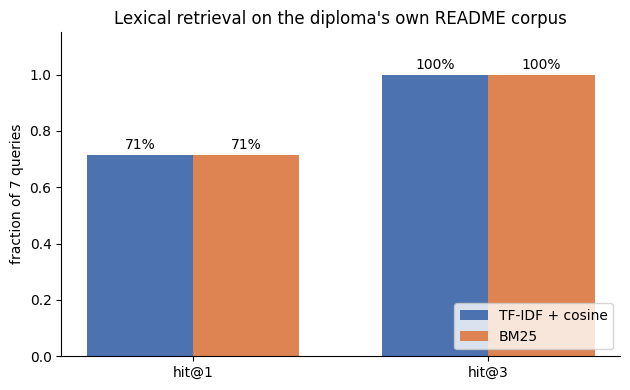

Read this honestly: 7 queries means each one is worth 14 percentage points.
A gap of one query between the two methods is not evidence that either is better.


In [6]:
# Step 6: the same two numbers as a chart, because a table of booleans is hard to compare at a glance.
import matplotlib
import matplotlib.pyplot as plt

metrics = ["hit@1", "hit@3"]
tfidf_scores = [tfidf_results[m].mean() for m in metrics]
bm25_scores = [bm25_results[m].mean() for m in metrics]

x = np.arange(len(metrics))
width = 0.36
fig, ax = plt.subplots(figsize=(6.4, 4.0))
bars1 = ax.bar(x - width / 2, tfidf_scores, width, label="TF-IDF + cosine", color="#4C72B0")
bars2 = ax.bar(x + width / 2, bm25_scores, width, label="BM25", color="#DD8452")
for bars in (bars1, bars2):
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.02,
                f"{bar.get_height():.0%}", ha="center", fontsize=10)
ax.set_xticks(x, metrics)
ax.set_ylim(0, 1.15)
ax.set_ylabel("fraction of 7 queries")
ax.set_title("Lexical retrieval on the diploma's own README corpus")
ax.legend(loc="lower right")
ax.spines[["top", "right"]].set_visible(False)
plt.tight_layout()
plt.show()

print("Read this honestly: 7 queries means each one is worth 14 percentage points.")
print("A gap of one query between the two methods is not evidence that either is better.")

## Part 5: The Failure That Defines RAG — Retrieval Is Not an Answer

Now ask the index something it cannot possibly know. The corpus is course READMEs; it contains no
hyperparameters, no lab results, no policy documents. Watch what comes back anyway.


In [7]:
# Step 7: three questions this corpus cannot answer. The retriever answers all three regardless.
for q in [
    "what learning rate should I use for LoRA fine-tuning?",
    "how many students failed the exam last semester?",
    "what is the refund policy for cancelled training days?",
]:
    hits = retrieve_tfidf(q, k=1)
    print("=" * 100)
    print(f"QUERY (unanswerable from this corpus): {q}")
    if hits:
        i, score = hits[0]
        row = chunks_df.iloc[i]
        print(f"  top result: score={score:.3f}  {row['rel']}  ::  {row['heading']}")
        print(f"  passage   : {row['text'][:170]}...")
    print()

print("None of those passages answers the question. Every one of them was returned with a score,")
print("and a generative model handed that passage would happily write a fluent answer around it.")


QUERY (unanswerable from this corpus): what learning rate should I use for LoRA fine-tuning?
  top result: score=0.169  Course 10/unit2-text-generation/README.md  ::  What This Unit Teaches
  passage   : What This Unit Teaches. Generating text with language models: GPT-style autoregressive generation, fine-tuning language models, prompt engineering, text-to-text systems, ...

QUERY (unanswerable from this corpus): how many students failed the exam last semester?
  top result: score=0.270  Course 08/README.md  ::  AIAT 122 — Deep Learning
  passage   : AIAT 122 — Deep Learning. **Course 08 · Semester 2 of the AI Diploma** Credit hours: 3 · Contact hours: 4/week · Total training hours: 64 (theory+practical) New students:...

QUERY (unanswerable from this corpus): what is the refund policy for cancelled training days?
  top result: score=0.291  Course 09/unit2-policy-value/README.md  ::  AIAT 123 - Reinforcement Learning
  passage   : AIAT 123 - Reinforcement Learning. **Unit training hou

## ✅ Summary

**What you actually did here** (every number computed live above):

- Indexed **72 real README files** from this repository — no downloads, no synthetic corpus
- Cut them into heading-delimited chunks and printed the size distribution before trusting the index
- Built two retrievers over the same chunks: TF-IDF + cosine, and BM25 implemented from its formula
- Scored both with hit@1 and hit@3 on 7 labelled questions, and said out loud what 7 queries is worth
- Produced, on purpose, three confident retrievals for three unanswerable questions

**The one sentence to keep:** a retriever returns the *nearest* passage, never the *correct* one — the
correctness check is a separate component, and in a RAG system it is the part teams most often skip.

**Where this goes next:** replace the TF-IDF vectors with a downloaded embedding model and you have the
dense half of a modern retrieval stack; add a reranker over the top-50 and you have the 2026 shape of it.
The evaluation discipline is the part that transfers unchanged.


## ⚠️ Where this breaks

**Lexical retrieval cannot match meaning.** Both methods here score on shared *words*. Ask for
"self-driving car" when the corpus says "autonomous vehicle" and you get nothing — there is no overlap to
score. This is exactly the gap dense embeddings (Unit 2, lesson 02) close, and it is why production
systems run both and merge the results rather than choosing.

**Our evaluation is small, and its labels are ours.** Seven queries, written by the same person who read
the corpus, graded at folder level. That is a smoke test. A real retrieval evaluation needs queries
collected from actual users, relevance judged by someone who did not build the index, and enough of them
that a difference of one query cannot move the headline number.

**Chunking is a hyperparameter disguised as plumbing.** Change `MIN_WORDS`, or split on paragraphs
instead of headings, and both rankings move. Nothing warns you. If you tune chunking against the same
seven queries you are grading on, you are fitting the test set.

**Retrieval quality is not system quality.** A 2026 result worth knowing: adding structurally smarter
retrieval to a multi-hop pipeline can *amplify* upstream noise rather than absorb it — Bao measured
36-67% larger degradation from clean text to high-error speech input under the more advanced retrieval
configurations ([arXiv:2608.22872](https://arxiv.org/abs/2608.22872)). Measure the system, not the
retriever alone.

**And the corpus itself is an attack surface.** Everything above assumes the indexed documents are
trustworthy. When a retrieved passage reaches a model that can act, hostile text inside that passage
becomes an instruction — the indirect prompt injection problem raised in Unit 5, lesson 01.


## 📚 References

The origin of retrieval-augmented generation, how it is evaluated, and where it went:

1. Lewis, P., Perez, E., Piktus, A., Petroni, F., Karpukhin, V., et al. (2020). *Retrieval-Augmented Generation for Knowledge-Intensive NLP Tasks*. NeurIPS 2020. [arXiv:2005.11401](https://arxiv.org/abs/2005.11401)
2. Es, S., James, J., Espinosa-Anke, L., & Schockaert, S. (2023). *Ragas: Automated Evaluation of Retrieval Augmented Generation*. [arXiv:2309.15217](https://arxiv.org/abs/2309.15217) — reference-free metrics (faithfulness, answer relevance) that make a RAG pipeline gradeable.
3. Edge, D., Trinh, H., Cheng, N., Bradley, J., Chao, A., et al. (2024). *From Local to Global: A Graph RAG Approach to Query-Focused Summarization*. [arXiv:2404.16130](https://arxiv.org/abs/2404.16130) — graph-indexed retrieval for corpus-level questions that chunk retrieval cannot answer.
4. Zhang, Y., Li, M., Long, D., Zhang, X., Lin, H., et al. (2025). *Qwen3 Embedding: Advancing Text Embedding and Reranking Through Foundation Models*. [arXiv:2506.05176](https://arxiv.org/abs/2506.05176) — the dense retriever and reranker you would swap in for the TF-IDF vectors above.
5. Singh, A., Ehtesham, A., Kumar, S., Talaei Khoei, T., & Vasilakos, A. V. (2025). *Agentic Retrieval-Augmented Generation: A Survey on Agentic RAG*. [arXiv:2501.09136](https://arxiv.org/abs/2501.09136) — retrieval that plans and re-queries instead of doing one fixed lookup.
6. Bao, Z. (2026). *Better Retrieval, Worse Robustness: How Multi-hop RAG Amplifies Upstream ASR Errors*. [arXiv:2608.22872](https://arxiv.org/abs/2608.22872) — why a better retriever can make a worse system.
